# Activity 1: Data Science with Google Colab
### eMathrix Education — Data Science & Data Analytics

**▶ Step 1 (do this first, before any code):** answer the **class intake form** — it collects your identity and a
quick prior-knowledge check: **https://forms.gle/Z2AJpKTMx5CZcdFq7** (opens in a new tab).
Pagkatapos ninyong sagutan ang intake form, saka kayo magpatuloy sa Colab sa ibaba.

In this activity you will then connect **your own Google Form survey** to Colab and turn your responses into charts.

**The flow today:**
1. **Answer the class intake form** (link above) ← Step 1
2. Make a short Google Form of your own (with linked Sheet)
3. Get a few responses
4. Copy your Sheet ID
5. Connect Colab to your Sheet
6. Build charts from your own data

Run each cell by clicking it and pressing **Shift + Enter**. Go in order, top to bottom.


---
## Before you touch any code: make your form

1. Go to **forms.google.com** and create a new form. Keep it short, 4 to 6 questions, mostly multiple choice.
2. In the form, click the **Responses** tab, then the green Sheets icon, then **Create spreadsheet**. This links a Google Sheet that fills automatically.
3. **Important:** fill out your own form 5 or 6 times so you have data to chart. No responses means empty charts later. Pwede rin kayong mag-sagutan ng katabi nyo.
4. Make sure the Google account you use here in Colab is the **same account that owns the form.** Magkaiba ang account, hindi gagana ang koneksyon.


---
## Get your Sheet ID

Open your linked Google Sheet. Look at the address bar. The URL looks like this:

`https://docs.google.com/spreadsheets/d/`**`1AbCdEfGhIjKlMnOpQrStUvWxYz1234567890`**`/edit`

The **bold part between `/d/` and `/edit`** is your Sheet ID. Copy it. You'll paste it in Step 4.

> **Important — this is just an example.** The ID above (`1AbCdEfGhIjKlMnOpQrStUvWxYz1234567890`) is a fake placeholder, only to show you what a Sheet ID looks like. It will **not** work. Once you're working on your own, you **must** replace it with the ID from **your own** Google Sheet, signed in with **your own** Google account that owns the form.
>
> Halimbawa lang ito. Palitan nyo ng sarili nyong Sheet ID at gamitin ang sarili nyong Google account kapag kayo na ang gagawa.


---
## Step 1: Install the tools

This installs the libraries that let Colab talk to Google Sheets. Run it once.

In [1]:
!pip install gspread google-auth

In [4]:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

print("Connected to Google!")
print("Ready to open your Google Sheet.")

Connected to Google!
Ready to open your Google Sheet.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import gspread
from google.auth import default
from google.colab import auth

print("Setup complete!")

Setup complete!


## Step 2: Load the libraries

This brings in pandas (for tables), matplotlib (for charts), and the Google connection tools.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import gspread
from google.auth import default
from google.colab import auth

print("Setup complete!")

Setup complete!


## Step 3: Log in to Google

**Heads up before you run this:** a popup will appear asking you to choose your Google account and allow access.

- Pick **your own** Google account — the one that **owns your form**. During class, do **not** use the trainer's example account; sign in as yourself.
- Click through every **Allow** / **Continue** screen.
- The popup sometimes hides behind this window or gets blocked. If nothing happens, check for a blocked-popup icon in your address bar, or look behind the browser window.

Tandaan: sariling account nyo ang gamitin, hindi ang account ng trainer.


In [5]:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

print("Connected to Google!")
print("Ready to open your Google Sheet.")

Connected to Google!
Ready to open your Google Sheet.


## Step 4: Connect to YOUR sheet

Replace the placeholder below with your **own** Sheet ID (the one you copied earlier), then run the cell.

The starting value `PASTE_YOUR_SHEET_ID_HERE` is **just a placeholder** — it will fail on purpose until you swap in your real ID. We set the ID **once here** and reuse it for the rest of the notebook, so you only paste it in one place.


In [ ]:
# ==== PASTE YOUR OWN SHEET ID BETWEEN THE QUOTES ====
SHEET_ID = "PASTE_YOUR_SHEET_ID_HERE"
# =====================================================

# Connect and pull the data once
try:
    sheet = gc.open_by_key(SHEET_ID).get_worksheet(0)
    data = sheet.get_all_values()

    if len(data) > 1:
        df = pd.DataFrame(data[1:], columns=data[0])
        print(f"SUCCESS! Connected to your survey.")
        print(f"Responses found: {len(df)}")
        print(f"Questions (columns): {len(df.columns)}")
        print("\nYour questions:")
        for i, col in enumerate(df.columns):
            short = col[:60] + "..." if len(col) > 60 else col
            print(f"  Column {i}: {short}")
    else:
        print("Connected, but no responses yet.")
        print("Go fill out your form a few times, then run this cell again.")

except Exception as e:
    print(f"Connection failed: {e}")
    print("\nCheck these:")
    print("1. Is your SHEET_ID pasted correctly (no extra spaces)?")
    print("2. Are you logged in with the account that owns the form?")
    print("3. Did you run Step 3 first?")

In [6]:
# ==== PASTE YOUR OWN SHEET ID BETWEEN THE QUOTES ====
SHEET_ID = "1lHBw4dResm71y_p-t0UXBuNSAH5OYfkK6SoLgAB_RaE"
# =====================================================

# Connect and pull the data once
try:
    sheet = gc.open_by_key(SHEET_ID).get_worksheet(0)
    data = sheet.get_all_values()

    if len(data) > 1:
        df = pd.DataFrame(data[1:], columns=data[0])
        print(f"SUCCESS! Connected to your survey.")
        print(f"Responses found: {len(df)}")
        print(f"Questions (columns): {len(df.columns)}")
        print("\nYour questions:")
        for i, col in enumerate(df.columns):
            short = col[:60] + "..." if len(col) > 60 else col
            print(f"  Column {i}: {short}")
    else:
        print("Connected, but no responses yet.")
        print("Go fill out your form a few times, then run this cell again.")

except Exception as e:
    print(f"Connection failed: {e}")
    print("\nCheck these:")
    print("1. Is your SHEET_ID pasted correctly (no extra spaces)?")
    print("2. Are you logged in with the account that owns the form?")
    print("3. Did you run Step 3 first?")

SUCCESS! Connected to your survey.
Responses found: 35
Questions (columns): 11

Your questions:
  Column 0: Timestamp
  Column 1: 1. When do you most often find yourself doom scrolling?
  Column 2: 2. How many hours do you spend on social media each day?  
  Column 3: 3. How often do you lose track of time while scrolling throu...
  Column 4:   4. Which of these platforms do you most commonly use when ...
  Column 5:   5. What usually triggers you to start doom scrolling?  (On...
  Column 6:   6. How do you usually feel after doom scrolling?  
  Column 7: 7. Approximately how long do you typical doom scrolling?
  Column 8: 8. Have you ever tried to reduce or stop your doom scrolling...
  Column 9:   9. To what extent do you agree with the following statemen...
  Column 10: 10. Which strategy do you think would be most effective in r...


## Step 5: See your full data table

This shows everything you collected as a clean table. The **Column** numbers shown above are what you'll use to pick which question to chart.

In [7]:
if len(data) > 1:
    print(f"Rows (responses): {len(df)}")
    print(f"Columns (questions): {len(df.columns)}")
    print("\nYour complete data:")
    from IPython.display import display
    display(df)
else:
    print("No responses yet. Fill out your form first, then re-run Step 4.")

Rows (responses): 35
Columns (questions): 11

Your complete data:


,Timestamp,1. When do you most often find yourself doom scrolling?,2. How many hours do you spend on social media each day?,3. How often do you lose track of time while scrolling through negative or distressing content?,4. Which of these platforms do you most commonly use when doom scrolling? (Choose only 3),5. What usually triggers you to start doom scrolling? (Only one that you think really triggers it),6. How do you usually feel after doom scrolling?,7. Approximately how long do you typical doom scrolling?,8. Have you ever tried to reduce or stop your doom scrolling habits?,"9. To what extent do you agree with the following statement? \n\n ""Doom scrolling negatively affects my mental well-being.""",10. Which strategy do you think would be most effective in reducing doom scrolling?
0,13/07/2026 16:11:01,Late at night before sleeping,1–2 hours,Rarely,Instagram,Boredom,Motivated,31–60 minutes,"Yes, successfully",Neutral,Taking regular breaks from social media
1,13/07/2026 16:13:19,Randomly throughout the day,More than 6 hours,Often,"Youtube, Reddit",Boredom,Neutral,More than 2 hours,"Yes, but unsuccessfully",Neutral,Taking regular breaks from social media
2,13/07/2026 16:14:24,During school/work breaks,1–2 hours,Sometimes,Facebook,Habit,More informed,31–60 minutes,"No, but I plan to",Agree,Following more positive or educational content
3,13/07/2026 16:15:28,Early morning,3–4 hours,Rarely,Reddit,Habit,Mentally exhausted,31–60 minutes,"Yes, successfully",Strongly Agree,Deleting or limiting social media apps
4,13/07/2026 16:15:38,Late at night before sleeping,More than 6 hours,Sometimes,"Facebook, Instagram, Tiktok",Social media recommendations/algorithms,Mentally exhausted,More than 2 hours,"No, but I plan to",Neutral,Taking regular breaks from social media
5,13/07/2026 16:16:03,Randomly throughout the day,More than 6 hours,Often,"Facebook, Instagram, Tiktok",Fear of Missing Out (FOMO),Mentally exhausted,1–2 hours,"Yes, but unsuccessfully",Neutral,Taking regular breaks from social media
6,13/07/2026 16:16:10,Late at night before sleeping,Less than 1 hour,Rarely,"Facebook, X (Twitter), Youtube",Habit,Neutral,31–60 minutes,"Yes, successfully",Neutral,Taking regular breaks from social media
7,13/07/2026 16:16:34,I rarely or never doom scroll,3–4 hours,Never,"Facebook, Youtube",Social media recommendations/algorithms,Neutral,Less than 10 minutes,"No, and I do not plan to",Neutral,Turning off notifications
8,13/07/2026 16:21:23,During school/work breaks,3–4 hours,Sometimes,"Instagram, X (Twitter), Youtube",Habit,Mentally exhausted,10–30 minutes,"Yes, but unsuccessfully",Disagree,Turning off notifications
9,13/07/2026 16:21:23,Late at night before sleeping,3–4 hours,Often,"Instagram, X (Twitter), Tumblr",Personal stress or anxiety,Mentally exhausted,10–30 minutes,"Yes, but unsuccessfully",Strongly Agree,Taking regular breaks from social media


## Step 6: Bar chart of one question

A bar chart counts how many people picked each answer. Change the **`question_column`** number to look at a different question. Look at your column list from Step 4 to pick the number.

Bar chart for: 1. When do you most often find yourself doom scrolling?


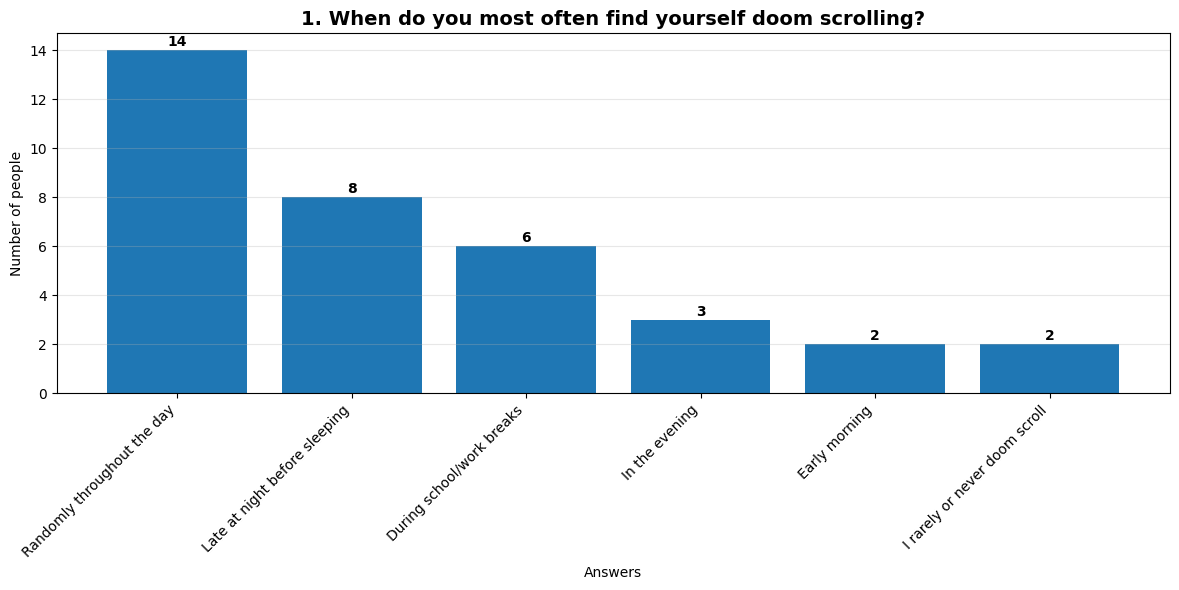

Most popular answer: 'Randomly throughout the day' (14 people)


In [8]:
question_column = 1   # change this number to chart a different question

if len(data) > 1 and question_column < len(df.columns):
    question_name = df.columns[question_column]
    answer_counts = df.iloc[:, question_column].value_counts()

    print(f"Bar chart for: {question_name}")

    plt.figure(figsize=(12, 6))
    bars = plt.bar(answer_counts.index.astype(str), answer_counts.values)

    for bar, count in zip(bars, answer_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(count), ha='center', va='bottom', fontweight='bold')

    plt.title(f'{question_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Answers')
    plt.ylabel('Number of people')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Most popular answer: '{answer_counts.index[0]}' ({answer_counts.iloc[0]} people)")
else:
    print("No data, or that question number does not exist. Check Step 4.")

**Notice:** the only thing you changed to chart a different question was the number in `question_column`. That's the whole trick. Try changing it to 2, then re-run this cell.

## Step 7: Pie chart of one question

A pie chart shows the same counts as percentages of the whole. Same idea, change `question_column` to pick a question.

Pie chart for:   5. What usually triggers you to start doom scrolling?  (Only one that you think really triggers it)


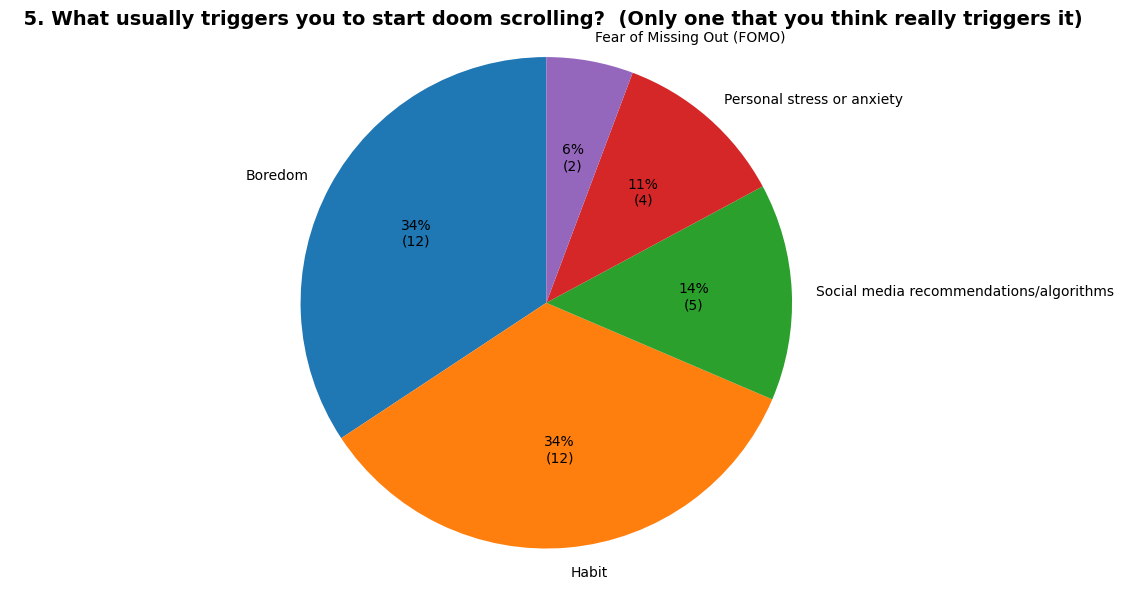

Most people answered: 'Boredom'


In [10]:
question_column = 5   # change this number to chart a different question

if len(data) > 1 and question_column < len(df.columns):
    question_name = df.columns[question_column]
    answer_counts = df.iloc[:, question_column].value_counts()

    print(f"Pie chart for: {question_name}")

    plt.figure(figsize=(8, 6))
    plt.pie(answer_counts.values,
            labels=answer_counts.index.astype(str),
            autopct=lambda p: f'{p:.0f}%\n({int(round(p*answer_counts.sum()/100))})',
            startangle=90)
    plt.title(f'{question_name}', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    print(f"Most people answered: '{answer_counts.index[0]}'")
else:
    print("No data, or that question number does not exist. Check Step 4.")

## Step 8: Compare two questions (crosstab)

This is where it gets interesting. A **crosstab** shows how answers to one question relate to answers to another, for example, do people who chose A on question 1 tend to choose X on question 2?

We show it as a grouped bar chart, which is the honest way to compare two categorical questions.

How '1. When do you most often find yourself doom scrolling?' relates to '2. How many hours do you spend on social media each day?  ':



2. How many hours do you spend on social media each day?,1–2 hours,3–4 hours,5–6 hours,Less than 1 hour,More than 6 hours
1. When do you most often find yourself doom scrolling?,,,,,
During school/work breaks,1,2,1,0,2
Early morning,0,1,0,0,1
I rarely or never doom scroll,1,1,0,0,0
In the evening,0,1,2,0,0
Late at night before sleeping,1,2,0,2,3
Randomly throughout the day,2,3,4,0,5


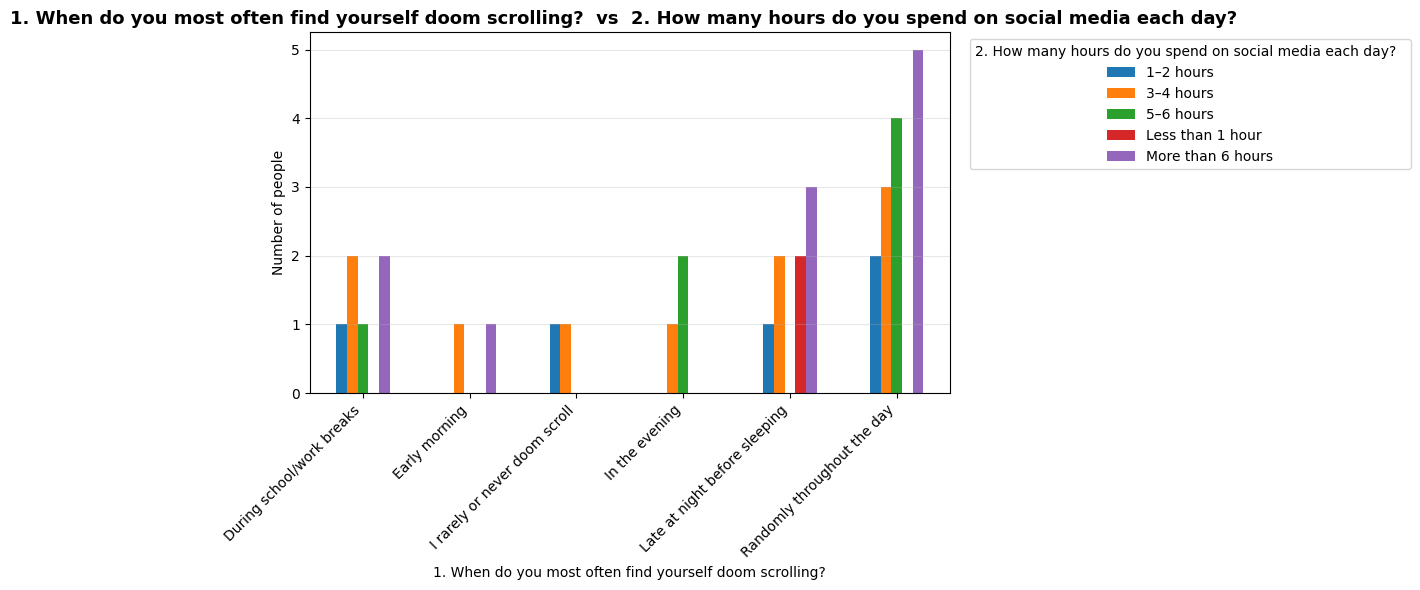

Each group of bars is one answer to the first question.
The colors show how those people answered the second question.


In [11]:
question_a = 1   # first question
question_b = 2   # second question

if len(data) > 1 and question_a < len(df.columns) and question_b < len(df.columns):
    name_a = df.columns[question_a]
    name_b = df.columns[question_b]

    # Build the crosstab: counts of each combination
    crosstab = pd.crosstab(df.iloc[:, question_a], df.iloc[:, question_b])

    print(f"How '{name_a}' relates to '{name_b}':\n")
    display(crosstab)

    crosstab.plot(kind='bar', figsize=(12, 6))
    plt.title(f'{name_a}  vs  {name_b}', fontsize=13, fontweight='bold')
    plt.xlabel(name_a)
    plt.ylabel('Number of people')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=name_b, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Each group of bars is one answer to the first question.")
    print("The colors show how those people answered the second question.")
else:
    print("No data, or one of those question numbers does not exist. Check Step 4.")

## Step 9: Full dashboard

This puts a pie chart for each of your questions into one picture, a quick overview of your whole survey.

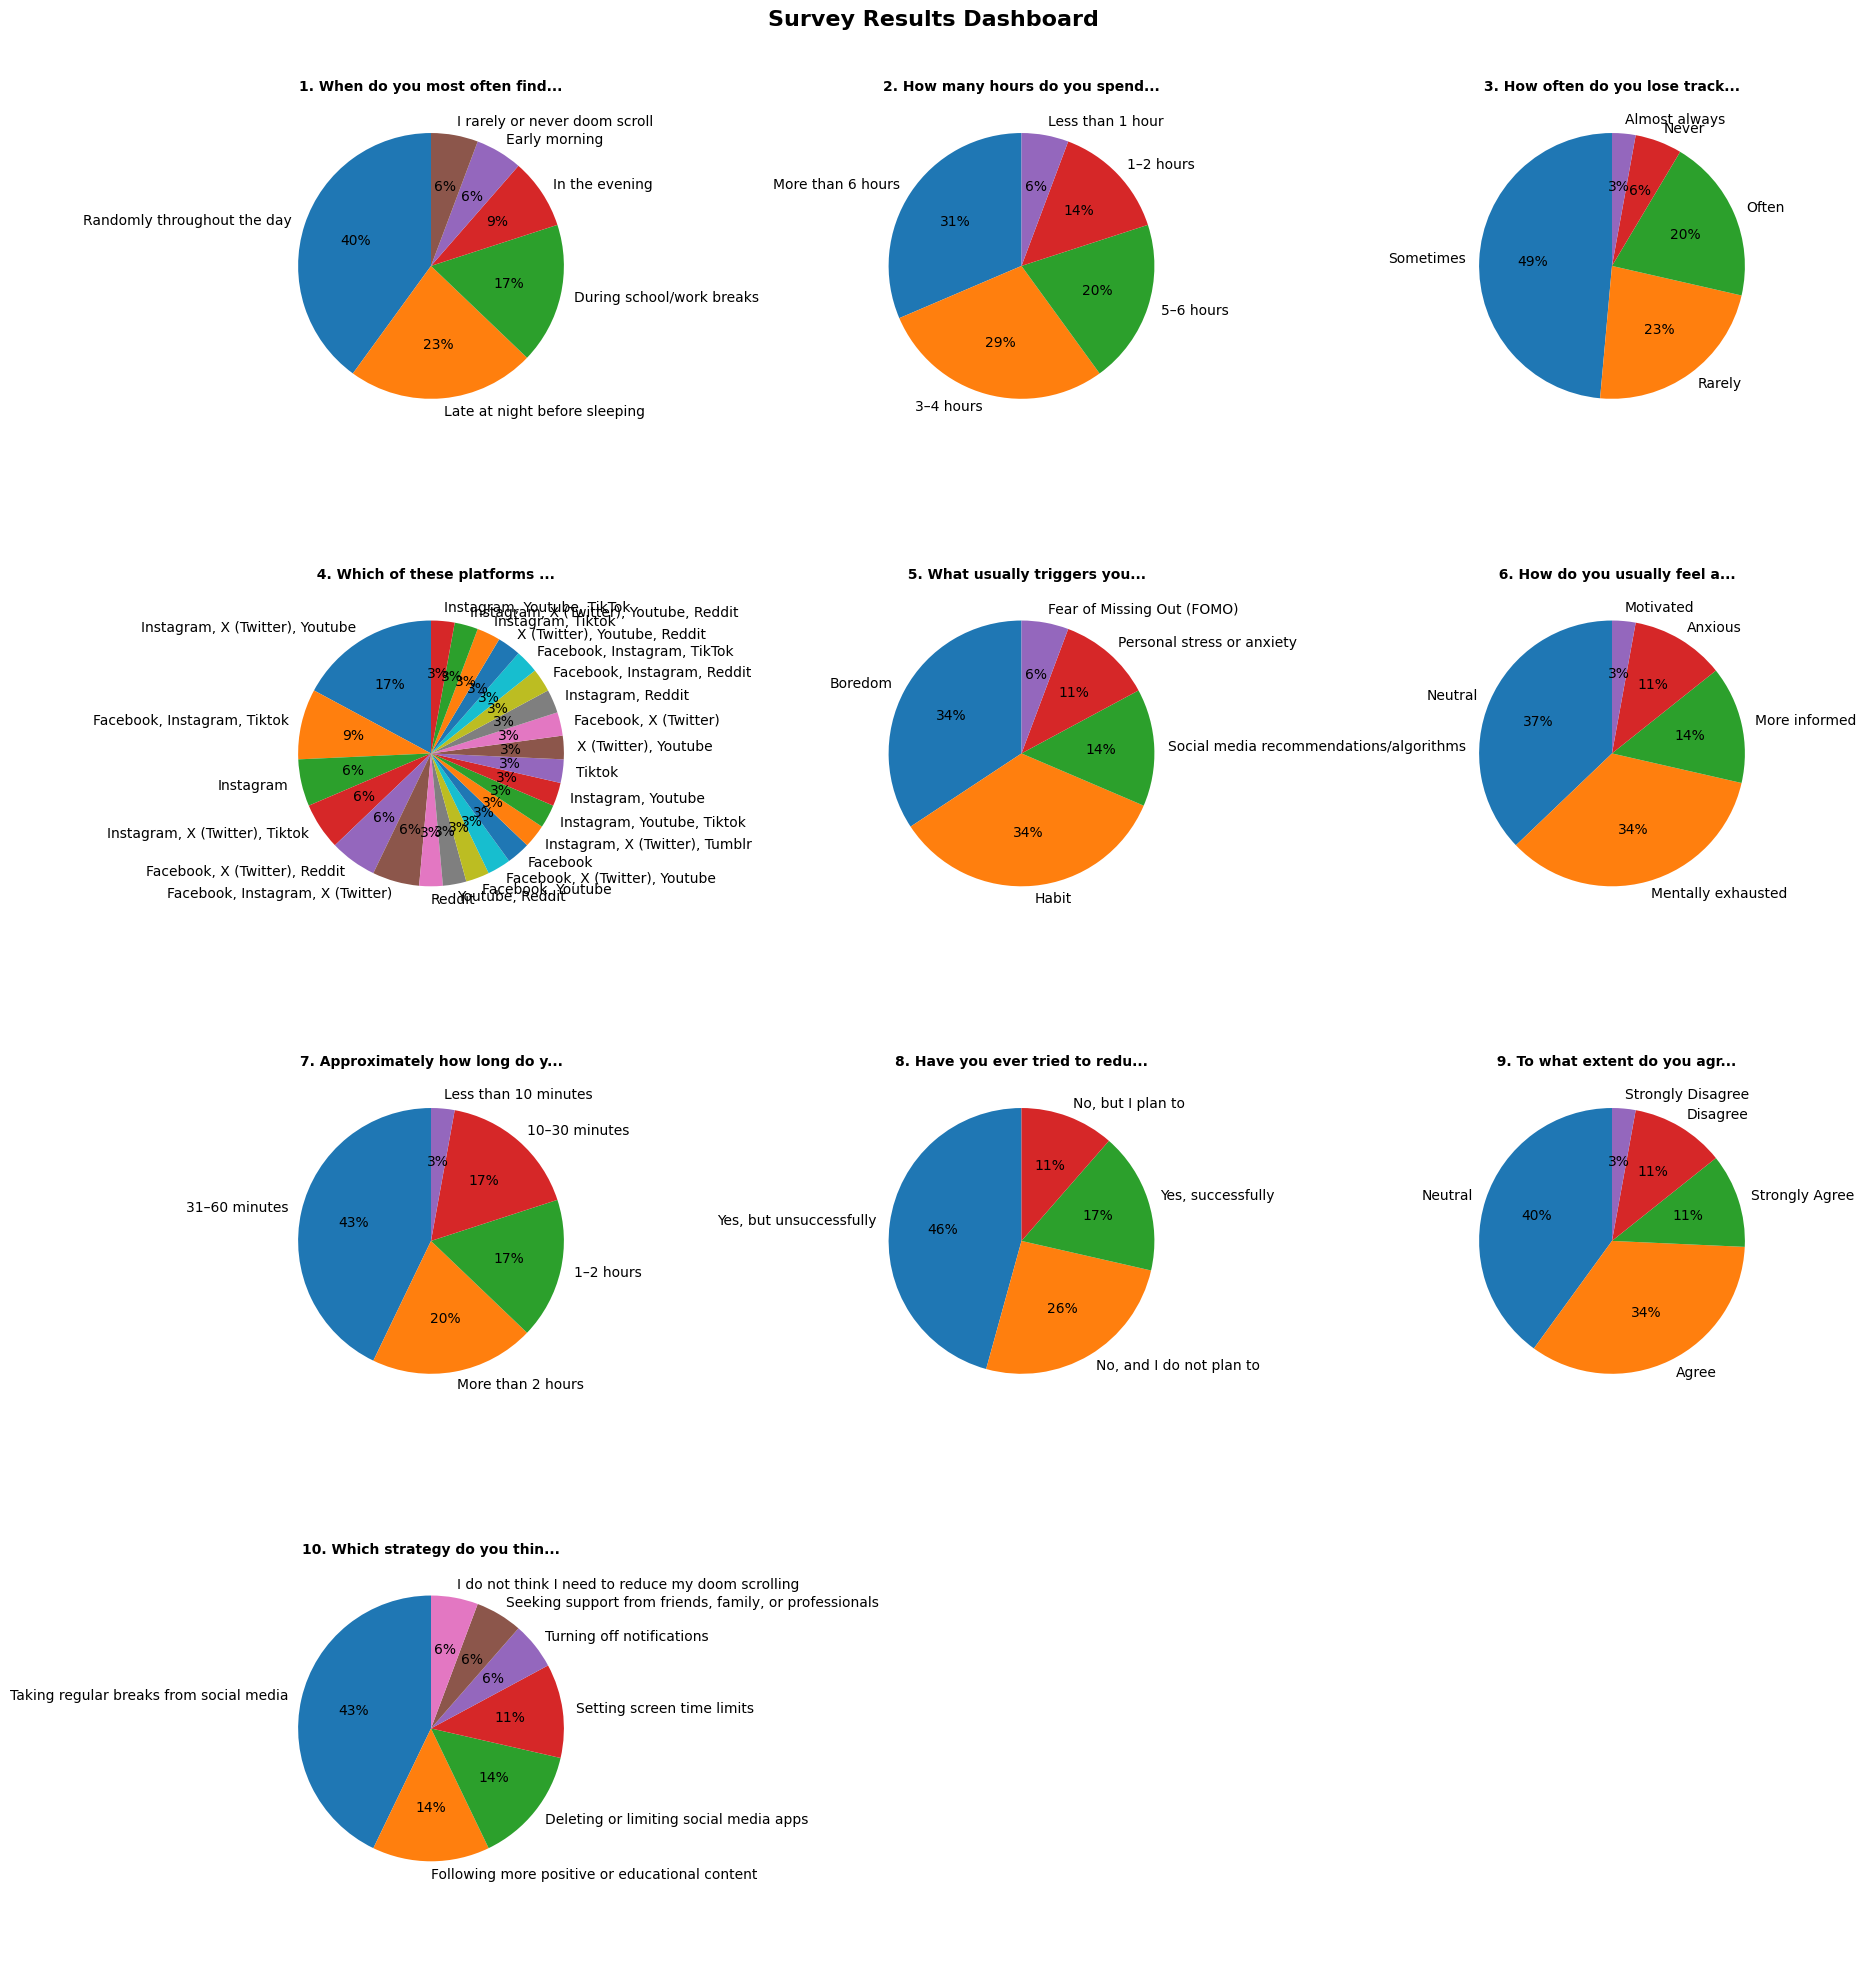

Dashboard created for 10 questions.


In [12]:
if len(data) > 1:
    question_cols = list(range(1, len(df.columns)))  # skip timestamp at column 0
    n = len(question_cols)

    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    fig.suptitle('Survey Results Dashboard', fontsize=16, fontweight='bold')

    axes_flat = axes.flatten() if n > 1 else [axes]

    for i, qcol in enumerate(question_cols):
        counts = df.iloc[:, qcol].value_counts()
        axes_flat[i].pie(counts.values,
                         labels=counts.index.astype(str),
                         autopct='%1.0f%%',
                         startangle=90)
        title = df.columns[qcol]
        title = title[:30] + "..." if len(title) > 30 else title
        axes_flat[i].set_title(title, fontsize=10, fontweight='bold')

    # turn off any leftover empty boxes
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Dashboard created for {n} questions.")
else:
    print("No data to build a dashboard yet. Fill out your form first.")

---
### You did it!

You connected live survey data to code and turned it into charts, the same thing data analysts do every day, just with bigger datasets.

Mahaba pa ang pwedeng gawin dito. Kung gusto nyo ng mas malalim na breakdown, tanong lang.

— eMathrix Education · Data Science & Data Analytics